# TP1 (a completer) : K-means + ACP — *Wine*

Remplacez chaque `...` et chaque `# TODO`. Le corrige est dans
`../notebooks/TP1_kmeans_acp.ipynb` (a ne consulter qu'en dernier recours).

**Objectif.** Retrouver, par clustering, les **3 cepages** de 178 vins decrits
par 13 mesures chimiques, sans utiliser l'etiquette ; puis valider et qualifier.

In [26]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [27]:
from sklearn.datasets import load_wine
ds = load_wine(as_frame=True)
X = ds.data
cepage = ds.target      # garde de cote pour la validation
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Exploration
**Consigne.** Affichez la moyenne et l'ecart-type de chaque variable pour
constater les differences d'echelle.

In [28]:

X.describe().loc["mean"], X.describe().loc["std"]


(alcohol                          13.000618
 malic_acid                        2.336348
 ash                               2.366517
 alcalinity_of_ash                19.494944
 magnesium                        99.741573
 total_phenols                     2.295112
 flavanoids                        2.029270
 nonflavanoid_phenols              0.361854
 proanthocyanins                   1.590899
 color_intensity                   5.058090
 hue                               0.957449
 od280/od315_of_diluted_wines      2.611685
 proline                         746.893258
 Name: mean, dtype: float64,
 alcohol                           0.811827
 malic_acid                        1.117146
 ash                               0.274344
 alcalinity_of_ash                 3.339564
 magnesium                        14.282484
 total_phenols                     0.625851
 flavanoids                        0.998859
 nonflavanoid_phenols              0.124453
 proanthocyanins                   0.572359
 co

## 2.a Standardisation
**Consigne.** Standardisez `X` (moyenne 0, ecart-type 1) avec `StandardScaler`.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

## 2.b Choisir k
**Consigne.** Pour `k` de 2 a 8, entrainez un `KMeans` et stockez l'inertie
(`.inertia_`) et la silhouette (`silhouette_score`). Tracez les deux courbes et
deduisez `k_best` (k qui maximise la silhouette).

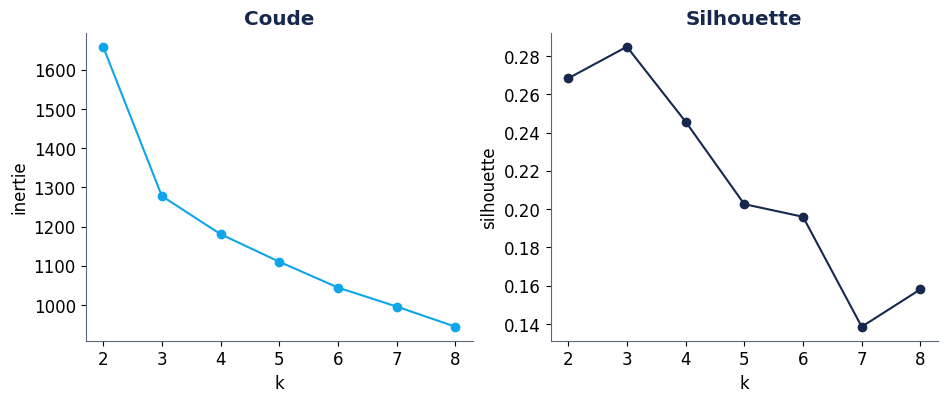

k retenu : 3


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std, km.labels_))

k_best = list(ks)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties, "-o", color=ACCENT)
ax1.set(title="Coude", xlabel="k", ylabel="inertie")
ax2.plot(list(ks), silhouettes, "-o", color=NAVY)
ax2.set(title="Silhouette", xlabel="k", ylabel="silhouette")
plt.show()
print("k retenu :", k_best)

## 3. Evaluation + validation
**Consigne.** Entrainez le modele final avec `k_best`. Affichez l'inertie, la
silhouette, puis **validez** : calculez l'`adjusted_rand_score` entre `cepage` et
les clusters, et affichez le `pd.crosstab`.

In [31]:
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=k_best, n_init=10, random_state=0).fit(X_std)
labels = km.labels_

print(f"Silhouette Score : {silhouette_score(X_std, labels):.3f}")
print(f"Adjusted Rand Score (ARI) : {adjusted_rand_score(cepage, labels):.3f}")


print("\nTableau croisé (Vrai Cepage vs Cluster prédit) :")
pd.crosstab(cepage, labels, rownames=['Cepage (réel)'], colnames=['Cluster (prédit)'])


Silhouette Score : 0.285
Adjusted Rand Score (ARI) : 0.897

Tableau croisé (Vrai Cepage vs Cluster prédit) :


Cluster (prédit),0,1,2
Cepage (réel),,,
0,0,0,59
1,65,3,3
2,0,48,0


## 4. Visualisation ACP
**Consigne.** Projetez `X_std` en 2D avec `PCA(n_components=2)`, puis tracez un
nuage de points colore par cluster (ajoutez les centres si vous le souhaitez).

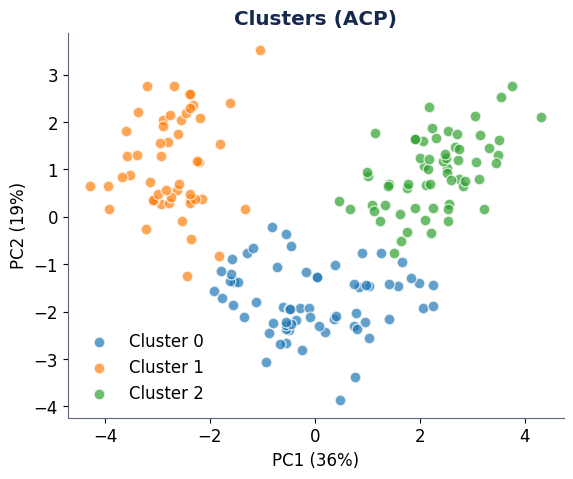

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_std)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.4, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    ax.scatter(coords[m, 0], coords[m, 1], label=f"Cluster {c}", alpha=0.7, edgecolors='w', s=60)
ax.set(title="Clusters (ACP)", xlabel=f"PC1 ({var[0]:.0%})", ylabel=f"PC2 ({var[1]:.0%})")
ax.legend(frameon=False)
plt.show()

## 5 & 6. Integration + qualification
**Consigne.** Ajoutez la colonne `cluster` a une copie de `X`, puis calculez le
profil moyen (`groupby`) des variables `alcohol`, `color_intensity`,
`flavanoids`, `proline` par cluster. Commentez les profils.

In [33]:
vins = X.copy()
vins["cluster"] = labels
cles = ["alcohol", "color_intensity", "flavanoids", "proline"]
profil = vins.groupby("cluster")[cles].mean()
profil

,alcohol,color_intensity,flavanoids,proline
cluster,,,,
0,12.250923,2.973077,2.050000,510.169231
1,13.134118,7.234706,0.818824,619.058824
2,13.676774,5.453548,3.003226,1100.225806


## A rendre
- Le `k` retenu et sa justification (coude + silhouette).
- L'ARI obtenu et votre interpretation du tableau croise.
- Une phrase de qualification par cluster.

**Bonus.** Refaites l'analyse **sans** standardisation : que devient l'ARI ?
Le `k` retenu et sa justification (coude + silhouette) :

Le k retenu est k=3. Le graphique du coude montre un ralentissement de la baisse d'inertie à partir de 3. le score de silhouette est optimal pour k=3 , ce qui confirme que les données se séparent naturellement en 3 groupes compacts et bien distincts.

L'ARI obtenu et votre interpretation du tableau croise :

6 vins sur 178 sont mal classés, tous provenant du cépage 1 :
3 sont assignés au cluster 1 et 3 au cluster 2.
Les cépages 0 et 2 sont parfaitement isolés.
Le cépage 1 est légèrement moins homogène : sa signature chimique chevauche un peu celle des deux autres cépages, ce qui explique les 6 erreurs.
Un ARI élevé (proche de 0.90) confirme malgré tout un accord très fort entre les clusters et les vrais cépages.

Une phrase de qualification par cluster :
Cluster 0 : Ce cluster regroupe des vins puissants et structurés, riches en alcool et en proline.
Cluster 1 : Ce sont des vins très colorés mais plus légers en tanins (flavanoïdes).
Cluster 2 : Ce cluster correspond à des vins légers et délicats, peu colorés, avec des taux réduits d'alcool, flavanoïdes et proline.


